In [1]:
import os
import polars as pl
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

COMBINED_ROOT = "/scratch/combined_datasets"
H5AD_ROOT = "/scratch/h5ad_outputs"


# Load cells by clusters

In [2]:
def get_leaf_type_df(
    table: str,
    filter_value: str,
    filter_col: str = "project_id",
    id_col: str | None = None,
    label_col: str | None = None,
    cluster_project_id: str | None = None,
    cast_id_to_int: bool = True,
) -> pd.DataFrame:
    """
    Load cell-to-type assignments from 'clustermembership' or 'celltoclustermapping',
    join the cluster hierarchy to find each cell's leaf-level (deepest) assignment,
    and return a tidy DataFrame with columns: id, predicted_label.

    Parameters
    ----------
    table : str
        Table name: 'clustermembership' or 'celltoclustermapping'.
    filter_value : str
        Value to filter on (e.g. project_id or mapping_set).
    filter_col : str
        Column to filter on (default 'project_id').
    id_col : str, optional
        Cell ID column. Auto-detected: 'item' for clustermembership, 'source_cell' otherwise.
    label_col : str, optional
        Label column. Auto-detected: 'cluster' or 'target_cluster'.
    cluster_project_id : str, optional
        Restrict cluster hierarchy lookup to this project_id.  Needed when a mapping
        table contains entries for multiple taxonomies (e.g. patchseq has both
        visp_met_types and tasic_2018_visp_scrnaseq clusters).
    cast_id_to_int : bool
        Cast the id column to int64 (default True).
        Set False for WNM-style compound string IDs.

    Returns
    -------
    pd.DataFrame with columns ['id', 'predicted_label'],
    one row per cell at its deepest assigned type.
    """
    if id_col is None:
        id_col = "item" if table == "clustermembership" else "source_cell"
    if label_col is None:
        label_col = "cluster" if table == "clustermembership" else "target_cluster"

    df = (
        pl.read_delta(os.path.join(COMBINED_ROOT, table))
        .filter(pl.col(filter_col) == filter_value)
        .select([id_col, label_col])
    )

    df_clusters = pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    if cluster_project_id:
        df_clusters = df_clusters.filter(pl.col("project_id") == cluster_project_id)

    result = (
        df
        .join(df_clusters.select(["id", "level"]), left_on=label_col, right_on="id", how="left")
        .sort("level", descending=True, nulls_last=True)
        .group_by(id_col)
        .first()
        .select([id_col, label_col])
        .rename({id_col: "id", label_col: "predicted_label"})
        .to_pandas()
    )

    if cast_id_to_int:
        result["id"] = result["id"].astype("int64")
    return result


In [3]:
# Minnie65 cell types from native ClusterMembership (CSM hierarchical subtype)
# Each cell appears once per hierarchy level; keep the deepest (leaf) assignment.
minnie_csm_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="minnie65",
    filter_col="project_id",
)
print(f"Minnie CSM: {len(minnie_csm_df)} cells, {minnie_csm_df['predicted_label'].nunique()} types")
print(minnie_csm_df['predicted_label'].value_counts())
minnie_csm_df.head()


Minnie CSM: 35780 cells, 13 types
predicted_label
L4IT    7348
L6CT    7245
L2IT    5038
L3IT    4444
L5IT    3327
L6IT    2895
PTC     1587
DTC     1466
L5ET     865
ITC      662
STC      460
L5NP     267
L6SP     176
Name: count, dtype: int64


,id,predicted_label
0,564248,L6CT
1,591065,L6IT
2,230890,PTC
3,325999,L3IT
4,597148,L6CT


In [4]:
# Minnie EXC MET types — umap+knn label transfer from patchseq
adata_exc = ad.read_h5ad(os.path.join(H5AD_ROOT, "exc_minnie_met_umapknn.h5ad"))
minnie_met_exc_df = adata_exc.obs[["id", "predicted_label"]].copy()
minnie_met_exc_df["id"] = minnie_met_exc_df["id"].astype("int64")

# Minnie INH MET types — umap+knn label transfer from patchseq
adata_inh = ad.read_h5ad(os.path.join(H5AD_ROOT, "inh_minnie_met_umapknn.h5ad"))
minnie_met_inh_df = adata_inh.obs[["id", "predicted_label"]].copy()
minnie_met_inh_df["id"] = minnie_met_inh_df["id"].astype("int64")

print(f"Minnie MET EXC: {len(minnie_met_exc_df)} cells, {minnie_met_exc_df['predicted_label'].nunique()} types")
print(f"Minnie MET INH: {len(minnie_met_inh_df)} cells, {minnie_met_inh_df['predicted_label'].nunique()} types")
minnie_met_exc_df.head()


Minnie MET EXC: 49714 cells, 17 types
Minnie MET INH: 163 cells, 19 types


,id,predicted_label
0,23141,L6b
1,23332,L6 IT-1
2,23373,L5 IT-2
3,23382,L6 IT-1
4,23385,L5 IT-2


In [5]:
# Minnie EXC cell-to-cell nearest patchseq neighbors (from yy07_12)
# Each Minnie cell has up to 3 nearest patchseq neighbors recorded as cell IDs + distances.
adata_ctc_exc = ad.read_h5ad(os.path.join(H5AD_ROOT, "exc_minnie_met_umapknn_cellToCell.h5ad"))
minnie_ctc_exc_df = (
    adata_ctc_exc.obs[["id", "nn_1_id", "nn_1_dist", "nn_2_id", "nn_2_dist", "nn_3_id", "nn_3_dist"]]
    .copy()
)
minnie_ctc_exc_df["id"] = minnie_ctc_exc_df["id"].astype("int64")

print(f"Minnie CTC EXC: {len(minnie_ctc_exc_df)} cells")
minnie_ctc_exc_df.head()


Minnie CTC EXC: 49714 cells


,id,nn_1_id,nn_1_dist,nn_2_id,nn_2_dist,nn_3_id,nn_3_dist
0,23141,610440978,0.941725,1010692386,1.070908,984034203,1.190587
1,23332,965535967,0.690688,983928133,0.690846,794963377,0.804676
2,23373,893401406,1.537057,850968263,1.543387,645834123,1.554805
3,23382,965535967,0.677635,794963377,0.719848,896619350,0.771412
4,23385,906532711,1.447108,971586225,1.453609,645834123,1.456139


In [6]:
# Patchseq MET types (EXC + INH) — ClusterMembership to visp_met_types taxonomy
# ClusterMembership for patchseq spans two taxonomies (visp_met_types + tasic_2018);
# restrict the cluster hierarchy join to visp_met_types so only MET-type leaf
# assignments (level=2) are returned.
patchseq_met_exc_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="visp_exc_patchseq",
    filter_col="project_id",
    cluster_project_id="visp_met_types",
)
patchseq_met_inh_df = get_leaf_type_df(
    table="clustermembership",
    filter_value="visp_inh_patchseq",
    filter_col="project_id",
    cluster_project_id="visp_met_types",
)
print(f"Patchseq EXC MET: {len(patchseq_met_exc_df)} cells, {patchseq_met_exc_df['predicted_label'].nunique()} types")
print(f"Patchseq INH MET: {len(patchseq_met_inh_df)} cells, {patchseq_met_inh_df['predicted_label'].nunique()} types")
patchseq_met_exc_df.head()


Patchseq EXC MET: 384 cells, 17 types
Patchseq INH MET: 495 cells, 28 types


,id,predicted_label
0,926866005,L2/3 IT
1,724539260,L6 CT-1
2,681931335,L5 IT-1
3,893401406,L5 IT-2
4,1036259470,L6b


In [7]:
# Patchseq T-types (Tasic 2018) — CellToClusterMapping for EXC and INH
# Tasic hierarchy: level 0 (cell) → 1 (class) → 2 (subclass) → 3 (cluster = T-type leaf)
patchseq_ttype_exc_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_exc_patchseq_ttype_mapping",
    filter_col="mapping_set",
    cluster_project_id="tasic_2018_visp_scrnaseq",
)
patchseq_ttype_inh_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_inh_patchseq_ttype_mapping",
    filter_col="mapping_set",
    cluster_project_id="tasic_2018_visp_scrnaseq",
)
print(f"Patchseq EXC T-types: {len(patchseq_ttype_exc_df)} cells, {patchseq_ttype_exc_df['predicted_label'].nunique()} types")
print(f"Patchseq INH T-types: {len(patchseq_ttype_inh_df)} cells, {patchseq_ttype_inh_df['predicted_label'].nunique()} types")
patchseq_ttype_exc_df.head()


Patchseq EXC T-types: 1528 cells, 31 types
Patchseq INH T-types: 2759 cells, 54 types


,id,predicted_label
0,935795108,L6 IT VISp Penk Fst
1,919917343,L6 CT VISp Ctxn3 Sla
2,926754976,L6 IT VISp Col18a1
3,927489061,L6b Col8a1 Rprm
4,898683305,L5 PT VISp C1ql2 Ptgfr


In [8]:
# WNM MET types — CellToClusterMapping to visp_met_types taxonomy
# NOTE: WNM cell IDs are compound strings (e.g. '182709_6984-X2452-Y12423_reg')
# and cannot be cast to int. cast_id_to_int=False keeps them as strings.
wnm_met_df = get_leaf_type_df(
    table="celltoclustermapping",
    filter_value="visp_exc_wnm_mettype_mapping",
    filter_col="mapping_set",
    cluster_project_id="visp_met_types",
    cast_id_to_int=False,
)
print(f"WNM MET: {len(wnm_met_df)} cells, {wnm_met_df['predicted_label'].nunique()} types")
print(wnm_met_df['predicted_label'].value_counts())
wnm_met_df.head()


WNM MET: 341 cells, 15 types
predicted_label
L2/3 IT           57
L5 ET-1 Chrna6    56
L5 ET-3           47
L4/L5 IT          41
L5 ET-2           40
L6 CT-2           23
L4 IT             20
L6b               17
L6 CT-1           16
L5/L6 IT Car3     10
L5 IT-2            8
L5 NP              3
L6 IT-2            1
L6 IT-1            1
L6 IT-3            1
Name: count, dtype: int64


,id,predicted_label
0,220308_6054-X20031-Y16355_reg,L6 CT-1
1,191807_6822-X4235-Y21316_reg,L5 ET-2
2,191812_7414-X5193-Y24236_reg,L4/L5 IT
3,211550_7718-X19461-Y16950_reg,L5 ET-1 Chrna6
4,191807_7326-X5555-Y22776_reg,L5 ET-3


# Load cells x features

## Feature schemas

Read feature definitions (metadata about each feature column) and cell × feature matrices
for all datasets from the combined delta lake.

| Variable | Source | Contents |
|---|---|---|
| `featdef_csm_df` | `cellfeaturedefinition` (top-level) | 87 CSM + UMAP + coordinate feature definitions |
| `featdef_visp_exc_df` | `cellfeaturedefinition/visp_exc` | 50 patchseq EXC morph feature definitions |
| `featdef_visp_inh_df` | `cellfeaturedefinition/visp_inh` | 46 patchseq INH morph feature definitions |
| `featdef_minnie_exc_skel_df` | `cellfeaturedefinition/minnie_exc_skel_keys` | 55 Minnie EXC skeleton-key feature definitions |
| `featdef_minnie_inh_skel_df` | `cellfeaturedefinition/minnie_inh_skel_keys` | 51 Minnie INH skeleton-key feature definitions |
| `feats_csm_df` | `cellfeatures/csm_cluster_features` | 35,787 cells × 82 CSM morpho features |
| `feats_csm_umap_df` | `cellfeatures/csm_cluster_features_umap` | 35,787 cells × 2 UMAP coords |
| `feats_minnie_coords_df` | `cellfeatures/minnie65_std_transform_coordinates` | 133,969 cells × 3 soma coordinates |
| `feats_minnie_exc_skel_df` | `cellfeatures/minnie_exc_skel_keys` | 49,714 EXC cells × 55 skel-key features |
| `feats_minnie_inh_skel_df` | `cellfeatures/minnie_inh_skel_keys` | 163 INH cells × 51 skel-key features |
| `feats_patchseq_exc_df` | `cellfeatures/exc_morph_features` | 734 patchseq EXC cells × 50 morph features |
| `feats_patchseq_inh_df` | `cellfeatures/inh_morph_features` | 520 patchseq INH cells × 46 morph features |


In [9]:
# Feature definitions — metadata about each feature column

# Top-level: CSM cluster features, UMAP, and soma coordinates (all Minnie/Microns)
featdef_csm_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition')).to_pandas()

# VISp patchseq morph features (EXC and INH)
featdef_visp_exc_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition', 'visp_exc')).to_pandas()
featdef_visp_inh_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition', 'visp_inh')).to_pandas()

# Minnie skeleton-key morph features (EXC and INH)
featdef_minnie_exc_skel_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition', 'minnie_exc_skel_keys')).to_pandas()
featdef_minnie_inh_skel_df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeaturedefinition', 'minnie_inh_skel_keys')).to_pandas()

print(f'CSM feature definitions:          {len(featdef_csm_df):>4d}  features')
print(f'VISp EXC morph definitions:       {len(featdef_visp_exc_df):>4d}  features')
print(f'VISp INH morph definitions:       {len(featdef_visp_inh_df):>4d}  features')
print(f'Minnie EXC skel-key definitions:  {len(featdef_minnie_exc_skel_df):>4d}  features')
print(f'Minnie INH skel-key definitions:  {len(featdef_minnie_inh_skel_df):>4d}  features')
featdef_csm_df.head()


CSM feature definitions:            87  features
VISp EXC morph definitions:         50  features
VISp INH morph definitions:         46  features
Minnie EXC skel-key definitions:    55  features
Minnie INH skel-key definitions:    51  features


,id,description,unit,data_type,range_min,range_max
0,x_umap,"umap low dimensional embedding feature, x coor...",ARBITRARY_UNIT,<f4,NaN,NaN
1,y_umap,"umap low dimensional embedding feature, y coor...",ARBITRARY_UNIT,<f4,NaN,NaN
2,nucleus_volume_um,Nucleus volume,MICRONS_CUBED,<f4,0.0,NaN
3,nucleus_area_um,Nucleus surface area,MICRONS_SQUARE,<f4,0.0,NaN
4,nuclear_area_to_volume_ratio,Nucleus surface area to volume ratio,MICRONS_INVERSE,<f4,0.0,NaN


In [10]:
# Cell x feature matrices — one row per cell, feature columns + id
# id is cast to int64 for all-numeric datasets; WNM cells keep string IDs.

def read_feats(sub_path: str, id_is_int: bool = True,
               project_id_filter: str | None = None) -> pd.DataFrame:
    """Read a cellfeatures delta table.
    Optionally filter to a specific project_id and cast id to int64.
    """
    df = pl.read_delta(os.path.join(COMBINED_ROOT, 'cellfeatures', sub_path))
    if project_id_filter is not None:
        df = df.filter(pl.col('project_id') == project_id_filter)
    result = df.to_pandas()
    if id_is_int:
        result['id'] = result['id'].astype('int64')
    return result

# Minnie CSM features (synapse-centric morphology used for CSM clustering)
feats_csm_df              = read_feats('csm_cluster_features')

# Minnie CSM UMAP embedding coordinates
feats_csm_umap_df         = read_feats('csm_cluster_features_umap')

# Minnie soma coordinates (standard-transform: y=0 at pia surface)
feats_minnie_coords_df    = read_feats('minnie65_std_transform_coordinates')

# Minnie skeleton-key morph features (comparable feature space to VISp morph)
feats_minnie_exc_skel_df  = read_feats('minnie_exc_skel_keys')
feats_minnie_inh_skel_df  = read_feats('minnie_inh_skel_keys')

# VISp patchseq morph features
# exc_morph_features contains both patchseq and WNM cells; split by project_id.
# WNM IDs are compound strings, patchseq IDs are numeric.
feats_patchseq_exc_df     = read_feats('exc_morph_features',
                                        project_id_filter='visp_exc_patchseq')
feats_wnm_exc_df          = read_feats('exc_morph_features', id_is_int=False,
                                        project_id_filter='visp_exc_wnm')
feats_patchseq_inh_df     = read_feats('inh_morph_features')

print(f'feats_csm_df:              {feats_csm_df.shape[0]:>7,} cells x {feats_csm_df.shape[1]-1:>3} features')
print(f'feats_csm_umap_df:         {feats_csm_umap_df.shape[0]:>7,} cells x {feats_csm_umap_df.shape[1]-1:>3} features')
print(f'feats_minnie_coords_df:    {feats_minnie_coords_df.shape[0]:>7,} cells x {feats_minnie_coords_df.shape[1]-1:>3} features')
print(f'feats_minnie_exc_skel_df:  {feats_minnie_exc_skel_df.shape[0]:>7,} cells x {feats_minnie_exc_skel_df.shape[1]-1:>3} features')
print(f'feats_minnie_inh_skel_df:  {feats_minnie_inh_skel_df.shape[0]:>7,} cells x {feats_minnie_inh_skel_df.shape[1]-1:>3} features')
print(f'feats_patchseq_exc_df:     {feats_patchseq_exc_df.shape[0]:>7,} cells x {feats_patchseq_exc_df.shape[1]-1:>3} features')
print(f'feats_wnm_exc_df:          {feats_wnm_exc_df.shape[0]:>7,} cells x {feats_wnm_exc_df.shape[1]-1:>3} features')
print(f'feats_patchseq_inh_df:     {feats_patchseq_inh_df.shape[0]:>7,} cells x {feats_patchseq_inh_df.shape[1]-1:>3} features')
feats_csm_df.head()


feats_csm_df:               35,787 cells x  84 features
feats_csm_umap_df:          35,787 cells x   4 features
feats_minnie_coords_df:    133,969 cells x   5 features
feats_minnie_exc_skel_df:   49,714 cells x  57 features
feats_minnie_inh_skel_df:      163 cells x  53 features
feats_patchseq_exc_df:         389 cells x  52 features
feats_wnm_exc_df:              345 cells x  52 features
feats_patchseq_inh_df:         520 cells x  48 features


,id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,...,branch_svd0,branch_svd1,branch_svd2,branch_svd3,branch_svd4,ego_count_pca0,ego_count_pca1,ego_count_pca2,project_id,feature_set_id
0,485509,344.116638,269.338379,0.782695,4873741.0,0.017687,0.309179,1112.999878,1202.533447,537.425110,...,62.978085,0.950874,0.729539,-1.328438,4.192588,1.960875,0.805681,-0.739578,minnie65,csm_cluster_features
1,263203,254.538391,250.433167,0.983872,30756560.0,0.123807,0.397382,640.537720,934.029358,361.333221,...,31.198191,-4.262416,0.754856,1.729803,1.534398,0.588246,-0.777625,-0.096427,minnie65,csm_cluster_features
2,456177,338.026459,298.603607,0.883373,35204028.0,0.124294,0.366174,923.129578,1017.687988,365.622009,...,56.717365,4.266992,9.265330,-0.329062,7.591257,-0.729798,-0.946995,0.546816,minnie65,csm_cluster_features
3,461339,328.602386,300.213623,0.913608,38599868.0,0.126401,0.324381,1013.014954,1051.013306,1082.797363,...,34.661217,0.517283,3.532224,3.231579,-0.251822,0.552461,-0.534918,-0.287912,minnie65,csm_cluster_features
4,302377,292.694000,327.721680,1.119673,67134240.0,0.197033,0.349798,836.752563,1107.547852,977.260864,...,45.571911,-3.164315,4.887801,2.438147,0.188189,-0.621269,-0.941240,-0.753779,minnie65,csm_cluster_features


# Load Connectome (cell-to-cell connectivity schema)

In [11]:
# Cell-cell connectivity (long format)
conn_df = pl.read_delta(os.path.join(COMBINED_ROOT, "cellcellconnectivitylong"))
print(f"Connectivity: {conn_df.height:,} rows")
print("measurement_type values:", conn_df["measurement_type"].unique().to_list())

Connectivity: 1,592,196 rows
measurement_type values: ['SYNAPSE_COUNT', 'SUM_ANATOMICAL_SIZE']


---

# Visualisation

In [12]:
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np


def stretch_to_match(
    df_source: pd.DataFrame,
    df_target: pd.DataFrame,
    group_col: str,
) -> pd.DataFrame:
    """Resample *df_source* rows within each group to match *df_target* group counts.

    For each unique value of *group_col* in *df_target*, the corresponding rows in
    *df_source* are resampled (nearest-neighbour via np.linspace) to produce exactly
    as many rows as *df_target* has for that group.  Groups absent from *df_source*
    are silently skipped.  The returned DataFrame has the same group order as
    *df_target*.
    """
    parts = []
    seen: set = set()
    ordered_groups = [g for g in df_target[group_col]
                      if g not in seen and not seen.add(g)]  # type: ignore[func-returns-value]
    for group in ordered_groups:
        n_target = int((df_target[group_col] == group).sum())
        src_rows = df_source[df_source[group_col] == group]
        m = len(src_rows)
        if m == 0:
            continue
        idx = np.round(np.linspace(0, m - 1, n_target)).astype(int)
        parts.append(src_rows.iloc[idx].reset_index(drop=True))
    return pd.concat(parts, ignore_index=True)


def merge_strips(id_col: str, *specs) -> pd.DataFrame:
    """Inner-join several DataFrames on *id_col*, keeping only cells present in all.

    Each spec is one of:
        (df, [col1, col2, ...])                 – keep listed columns + id_col
        (df, [col1, ...], {'old': 'new', ...})  – also rename columns after selection

    Returns a single merged DataFrame.
    """
    result = None
    for spec in specs:
        df_in, cols = spec[0], spec[1]
        rename = spec[2] if len(spec) > 2 else {}
        keep = list({id_col} | set(cols))
        df_sel = df_in[keep].rename(columns=rename)
        result = df_sel if result is None else result.merge(df_sel, on=id_col, how="inner")
    return result.reset_index(drop=True)


def plot_strips(
    df: pd.DataFrame,
    features: list[dict] | None = None,
    labels: list[dict] | None = None,
    sort_by: list[str] | None = None,
    colorbar_position: str = "top",   # 'top' | 'bottom'
    average_by=None,  # str | list[str] | None — group cols for feature averaging
    fig=None,  # optional existing Figure or SubFigure
    strips: list[dict] | None = None,  # ordered mixed list; each dict has type="feature"|"label"
) -> plt.Figure:
    """Plot a sorted cell-strip figure.

    Parameters
    ----------
    df : pd.DataFrame
        One row per cell.  Must contain all columns referenced by *features* and *labels*.
    features : list of dict, optional
        Each dict: {'col': str, 'title': str, 'cmap': str}.
        Features appear left-to-right in list order.  Pass [] or None for no feature str ip.
    labels : list of dict, optional
        Each dict: {'col': str, 'title': str, 'colors': dict[str, str]}.
        Strips appear left-to-right after features.  A legend is added for each.
    sort_by : list of str, optional
        Column names (in *df*) to sort rows by, in priority order.  Independent of
        which columns are displayed.
    colorbar_position : 'top' | 'bottom'
        Where to place feature colorbars.  Ignored when *features* is empty.
    fig : matplotlib.figure.Figure or SubFigure, optional
        Existing figure to draw into.  When None (default) a new figure is
        created.  Pass a SubFigure to embed strips inside a larger layout.
    average_by : str or list of str, optional
        Column(s) to group by when averaging feature values.  Every cell in the
        same group receives the group mean as its feature value.  Label strips are
        unaffected.  Feature strip titles get an " (avg)" suffix.
    strips : list of dict, optional
        Ordered mixed list of strip descriptors.  Each dict must have a
        ``type`` key set to ``"feature"``, ``"label"``, or ``"heatmap"``,
        plus the fields that would appear in *features* or *labels*
        respectively.  When provided, *strips* takes precedence over
        *features* and *labels*, enabling arbitrary interleaving.
        Heatmap dict: {type, cols, title, cmap}.  *cols* is a list of
        column names in *df* that form the 2-D connectivity matrix.  A
        single shared colorbar is drawn; ``average_by`` averages each
        column identically to regular features.

    Returns
    -------
    matplotlib.figure.Figure
    """
    # When strips= is provided, derive features and labels from it (preserving order).
    if strips is not None:
        features = [dict({k: v for k, v in s.items() if k != "type"}) for s in strips if s.get("type") == "feature"]
        labels   = [dict({k: v for k, v in s.items() if k != "type"}) for s in strips if s.get("type") == "label"]
        strip_order = strips  # remember the interleaved order
    else:
        strip_order = None
    features = features or []
    labels   = labels   or []
    sort_by  = sort_by  or []

    # Heatmaps: extract column lists for average_by processing
    heatmap_strips = [s for s in (strip_order or []) if s.get("type") == "heatmap"]

    # Normalize average_by and compute group means for feature columns + heatmap cols
    if average_by is not None and isinstance(average_by, str):
        average_by = [average_by]
    if average_by is not None:
        feat_cols = [f["col"] for f in features]
        hm_cols   = [c for s in heatmap_strips for c in s.get("cols", [])]
        all_avg_cols = feat_cols + hm_cols
        if all_avg_cols:
            df = df.copy()
            df[all_avg_cols] = df.groupby(average_by)[all_avg_cols].transform("mean")

    # Sort rows
    if sort_by:
        df = df.sort_values(sort_by).reset_index(drop=True)
    n_cells = len(df)

    n_feats  = len(features)
    n_labels = len(labels)

    has_cb   = n_feats > 0
    n_rows   = 2 if has_cb else 1
    if has_cb:
        cb_row    = 0 if colorbar_position == "top" else 1
        strip_row = 1 if colorbar_position == "top" else 0
    else:
        cb_row    = None  # unused
        strip_row = 0

    # Column widths: feature strips wider, label strips narrow, legend axes
    FEAT_W   = 1.5
    LABEL_W  = 0.5
    LEG_W    = 2.2
    n_heatmaps = len([s for s in (strip_order or []) if s.get("type") == "heatmap"])
    n_strips = n_feats + n_labels + n_heatmaps
    n_cols = n_strips + n_labels  # strips | legends (heatmaps have no legend)

    HEATMAP_COL_W = 0.015  # width units per postsynaptic column in heatmap
    HEATMAP_MAX_W = 8.0    # cap total heatmap width
    if strip_order is not None:
        # Mixed ordering: assign column index according to strips list
        def _strip_width(s):
            if s["type"] == "heatmap":
                return min(HEATMAP_MAX_W, max(FEAT_W, len(s.get("cols", [])) * HEATMAP_COL_W))
            return FEAT_W if s["type"] == "feature" else LABEL_W
        strip_widths = [_strip_width(s) for s in strip_order]
    else:
        strip_widths = [FEAT_W] * n_feats + [LABEL_W] * n_labels
    width_ratios = strip_widths + [LEG_W] * n_labels

    # Figure width; minimum 2 inches if only labels and legends
    total_w = max(2.5, sum(width_ratios))
    fig_h = 8.0

    if n_rows == 2:
        height_ratios = ([0.06, 0.94] if colorbar_position == "top"
                         else [0.94, 0.06])
    else:
        height_ratios = [1]

    if fig is None:
        fig = plt.figure(figsize=(total_w, fig_h), layout="constrained")
    gs = fig.add_gridspec(
        n_rows, n_cols,
        height_ratios=height_ratios,
        width_ratios=width_ratios,
        wspace=0.04,
        hspace=0.04,
    )

    # ── Build ordered strip list (feature, label, or heatmap) ───────────────
    if strip_order is not None:
        ordered_strips = strip_order
    else:
        ordered_strips = ([dict(s, type="feature") for s in features]
                          + [dict(s, type="label") for s in labels])

    # Counters to look up per-type im handles for colorbars
    feat_ims: list = []  # (col_idx, im) pairs for individual feature strips
    hm_ims:   list = []  # (col_idx, im) pairs for heatmap strips (shared cb)

    for col_idx, strip in enumerate(ordered_strips):
        stype = strip["type"]
        if stype == "feature":
            vals = df[strip["col"]].values.reshape(-1, 1).astype(float)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            im = ax_strip.imshow(
                vals, aspect="auto", cmap=strip.get("cmap", "viridis"),
                vmin=np.nanmin(vals), vmax=np.nanmax(vals),
                interpolation="nearest",
            )
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            _title = strip.get("title", strip["col"])
            if average_by is not None:
                _title += " (avg)"
            ax_strip.set_title(_title, fontsize=8, pad=3)
            feat_ims.append((col_idx, im))
        elif stype == "heatmap":
            cols = strip.get("cols", [])
            mat = df[cols].values.astype(float)  # shape: (n_cells, n_post)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            _vmin_hm = strip.get("vmin", None)
            _vmax_hm = strip.get("vmax", None)
            im = ax_strip.imshow(
                mat, aspect="auto", cmap=strip.get("cmap", "viridis"),
                vmin=_vmin_hm, vmax=_vmax_hm,
                interpolation="nearest",
            )
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            _title = strip.get("title", "Connectivity")
            if average_by is not None:
                _title += " (avg)"
            ax_strip.set_title(_title, fontsize=8, pad=3)
            hm_ims.append((col_idx, im))
        else:  # label
            rgba_arr = np.array([
                mcolors.to_rgba(strip["colors"].get(v, "#cccccc"))
                for v in df[strip["col"]]
            ]).reshape(-1, 1, 4)
            ax_strip = fig.add_subplot(gs[strip_row, col_idx])
            ax_strip.imshow(rgba_arr, aspect="auto", interpolation="nearest")
            ax_strip.set_xticks([])
            ax_strip.set_yticks([])
            ax_strip.set_title(strip.get("title", strip["col"]), fontsize=8, pad=3)

    # ── Colorbars ────────────────────────────────────────────────────────────
    if has_cb:
        # Individual feature colorbars
        for col_idx, im in feat_ims:
            ax_cb = fig.add_subplot(gs[cb_row, col_idx])
            fig.colorbar(im, cax=ax_cb, orientation="horizontal")
            ax_cb.tick_params(labelsize=6)
            if colorbar_position == "bottom":
                ax_cb.xaxis.tick_bottom()
                ax_cb.xaxis.set_label_position("bottom")
        # Shared colorbar for heatmap strips (use first heatmap's image handle,
        # but normalise all heatmap images to the global min/max first)
        if hm_ims:
            # Use explicit vmin/vmax from first heatmap strip if provided;
            # otherwise fall back to the global data min/max.
            first_hm_strip = next(s for s in (strip_order or []) if s.get("type") == "heatmap")
            if first_hm_strip.get("vmin") is not None or first_hm_strip.get("vmax") is not None:
                all_hm_vals = np.concatenate([
                    im.get_array().ravel()  # type: ignore[union-attr]
                    for _, im in hm_ims
                ])
                vmin_hm = first_hm_strip.get("vmin", float(np.nanmin(all_hm_vals)))
                vmax_hm = first_hm_strip.get("vmax", float(np.nanmax(all_hm_vals)))
            else:
                all_hm_vals = np.concatenate([
                    im.get_array().ravel()  # type: ignore[union-attr]
                    for _, im in hm_ims
                ])
                vmin_hm, vmax_hm = np.nanmin(all_hm_vals), np.nanmax(all_hm_vals)
            for _, im in hm_ims:
                im.set_clim(vmin_hm, vmax_hm)
            # Draw a single shared colorbar anchored to the first heatmap strip
            first_hm_col, first_hm_im = hm_ims[0]
            ax_cb_hm = fig.add_subplot(gs[cb_row, first_hm_col])
            cb_hm = fig.colorbar(first_hm_im, cax=ax_cb_hm, orientation="horizontal")
            cb_hm.ax.tick_params(labelsize=6)
            if colorbar_position == "bottom":
                ax_cb_hm.xaxis.tick_bottom()
                ax_cb_hm.xaxis.set_label_position("bottom")
            # Spacer axes for remaining heatmap colorbar slots
            for col_idx, _ in hm_ims[1:]:
                ax_sp = fig.add_subplot(gs[cb_row, col_idx])
                ax_sp.axis("off")
        # Spacer axes for label/other strips in colorbar row
        for col_idx, strip in enumerate(ordered_strips):
            if strip["type"] not in ("feature", "heatmap"):
                ax_empty = fig.add_subplot(gs[cb_row, col_idx])
                ax_empty.axis("off")

    # ── Legend axes (one per label, span all rows; heatmaps have no legend) ─
    for k, lbl in enumerate(labels):
        col_idx = n_strips + k
        ax_leg = fig.add_subplot(gs[:, col_idx])
        present = sorted(df[lbl["col"]].unique())
        patches = [
            mpatches.Patch(color=lbl["colors"].get(v, "#cccccc"), label=v)
            for v in present
        ]
        ncol = 2 if len(present) > 20 else 1
        ax_leg.legend(
            handles=patches,
            title=lbl.get("title", lbl["col"]),
            fontsize=7, title_fontsize=8,
            loc="upper left", frameon=False,
            ncol=ncol, handlelength=1.1, handletextpad=0.5, columnspacing=0.8,
        )
        ax_leg.axis("off")

    return fig

def lookup_patchseq_neighbors(
    ctc_df: pd.DataFrame,
    patchseq_met_df: pd.DataFrame,
    patchseq_ttype_df: pd.DataFrame,
    k: int = 1,
) -> pd.DataFrame:
    """For each Minnie cell in *ctc_df*, look up the k-th nearest patchseq neighbor's
    MET type and T-type labels.

    Parameters
    ----------
    ctc_df : pd.DataFrame
        Cell-to-cell neighbor DataFrame with columns ``id`` (Minnie cell ID) and
        ``nn_{k}_id`` (patchseq cell ID of the k-th nearest neighbor).
    patchseq_met_df : pd.DataFrame
        Patchseq MET-type table with columns ``id`` and ``predicted_label``.
    patchseq_ttype_df : pd.DataFrame
        Patchseq T-type table with columns ``id`` and ``predicted_label``.
    k : int
        Which neighbor rank to use (1 = nearest, 2 = second nearest, 3 = third nearest).

    Returns
    -------
    pd.DataFrame
        One row per Minnie cell with columns:
        ``id``            – Minnie cell ID
        ``ps_id``         – patchseq neighbor cell ID (nn_{k}_id)
        ``ps_met_label``  – patchseq neighbor MET type
        ``ps_ttype_label``– patchseq neighbor T-type
    Cells where the neighbor ID is missing from either label table are dropped.
    """
    nn_id_col = f"nn_{k}_id"
    df = ctc_df[["id", nn_id_col]].rename(columns={nn_id_col: "ps_id"}).copy()
    # nn_k_id is stored as string in the h5ad obs; cast to int64 to match
    # patchseq label tables whose "id" column is cast to int64 by get_leaf_type_df.
    df = df.dropna(subset=["ps_id"])
    df["ps_id"] = df["ps_id"].astype("int64")

    # Join MET label for the patchseq neighbor
    ps_met = patchseq_met_df[["id", "predicted_label"]].rename(
        columns={"id": "ps_id", "predicted_label": "ps_met_label"}
    )
    df = df.merge(ps_met, on="ps_id", how="inner")

    # Join T-type label for the patchseq neighbor
    ps_ttype = patchseq_ttype_df[["id", "predicted_label"]].rename(
        columns={"id": "ps_id", "predicted_label": "ps_ttype_label"}
    )
    df = df.merge(ps_ttype, on="ps_id", how="inner")

    return df.reset_index(drop=True)


In [13]:
# ── Standard colour dictionaries ──────────────────────────────────────────────
# These can be reused across all demo calls.

# MET types: hex_color from visp_met_types taxonomy (level=2 = leaf clusters)
df_met_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "visp_met_types") & (pl.col("level") == 2))
    .select(["id", "hex_color"])
)
met_colors = dict(zip(df_met_clusters["id"].to_list(),
                      df_met_clusters["hex_color"].to_list()))

# CSM types: hex_color from minnie65 cluster schema (level=2 = leaf subtypes)
df_csm_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "minnie65") & (pl.col("level") == 2))
    .select(["id", "hex_color"])
)
csm_colors = dict(zip(df_csm_clusters["id"].to_list(),
                      df_csm_clusters["hex_color"].to_list()))

# Build Tasic T-type colour dict from cluster taxonomy
df_tasic_clusters = (
    pl.read_delta(os.path.join(COMBINED_ROOT, "cluster"))
    .filter((pl.col("project_id") == "tasic_2018_visp_scrnaseq") & (pl.col("level") == 3))
    .select(["id", "hex_color"])
)
ttype_colors = dict(zip(df_tasic_clusters["id"].to_list(),
                        df_tasic_clusters["hex_color"].to_list()))

print(f"met_colors: {len(met_colors)} types")
print(f"csm_colors: {len(csm_colors)} types")
print(f"ttype_colors: {len(ttype_colors)} types")


met_colors: 45 types
csm_colors: 13 types
ttype_colors: 111 types


In [14]:
# Build df_d2: Minnie EXC cells with morphological features + CSM label + MET label
df_d2 = merge_strips("id",
    (feats_csm_df, ["fraction_nuclear_folding", "syn_size_distribution_dendrite_p50"]),
    (minnie_csm_df, ["predicted_label"], {"predicted_label": "csm_label"}),
    (minnie_met_exc_df, ["predicted_label"], {"predicted_label": "met_label"}),
)
print(f"df_d2: {len(df_d2):,} cells")
df_d2.head()


df_d2: 29,322 cells


,fraction_nuclear_folding,id,syn_size_distribution_dendrite_p50,csm_label,met_label
0,0.017687,485509,4340,L2IT,L6b
1,0.123807,263203,4618,L4IT,L6 CT-2
2,0.124294,456177,5460,L3IT,L5 IT-2
3,0.126401,461339,5186,L5IT,L6 IT-2
4,0.197033,302377,4848,L4IT,L6 CT-2


/tmp/ipykernel_72818/3342426913.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[all_avg_cols] = df.groupby(average_by)[all_avg_cols].transform("mean")


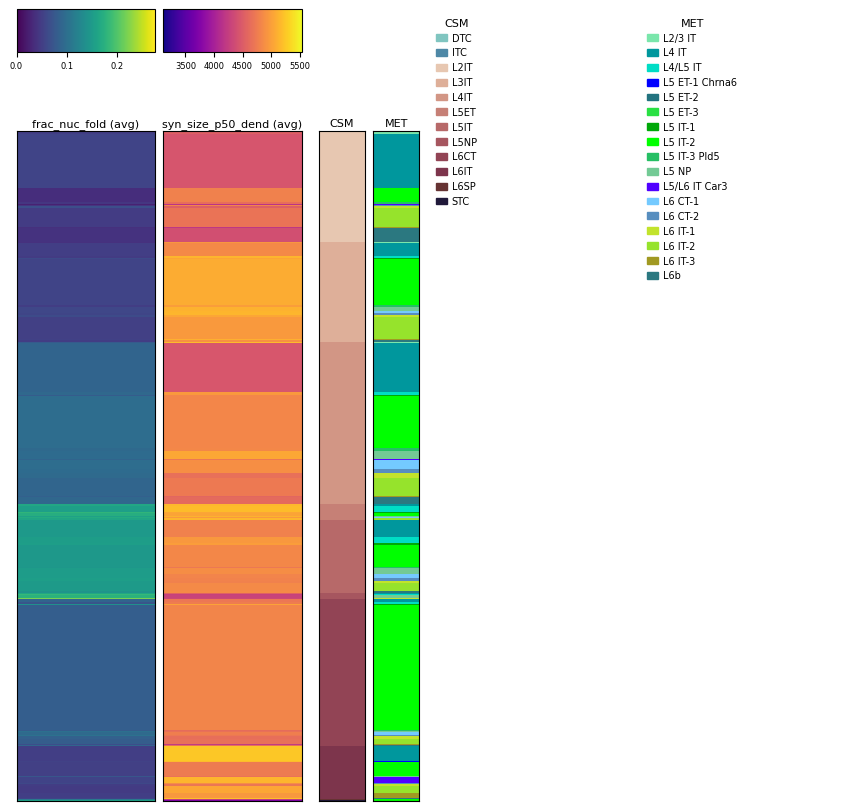

In [15]:
# Demo 4: Minnie EXC features averaged per (csm_label × met_label) block
# Primary sort: csm_label; secondary sort: met_label.
# Each unique (csm, met) block shows the group mean feature value.

fig = plot_strips(
    df_d2,
    features=[
        {"col": "fraction_nuclear_folding",           "title": "frac_nuc_fold",     "cmap": "viridis"},
        {"col": "syn_size_distribution_dendrite_p50", "title": "syn_size_p50_dend", "cmap": "plasma"},
    ],
    labels=[
        {"col": "csm_label", "title": "CSM", "colors": csm_colors},
        {"col": "met_label", "title": "MET", "colors": met_colors},
    ],
    sort_by=["csm_label", "met_label"],
    average_by=["csm_label", "met_label"],
    colorbar_position="top",
)
plt.show()


Demo 5 (cell-to-cell): 29,322 cells  (k=1)


/tmp/ipykernel_72818/3342426913.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[all_avg_cols] = df.groupby(average_by)[all_avg_cols].transform("mean")


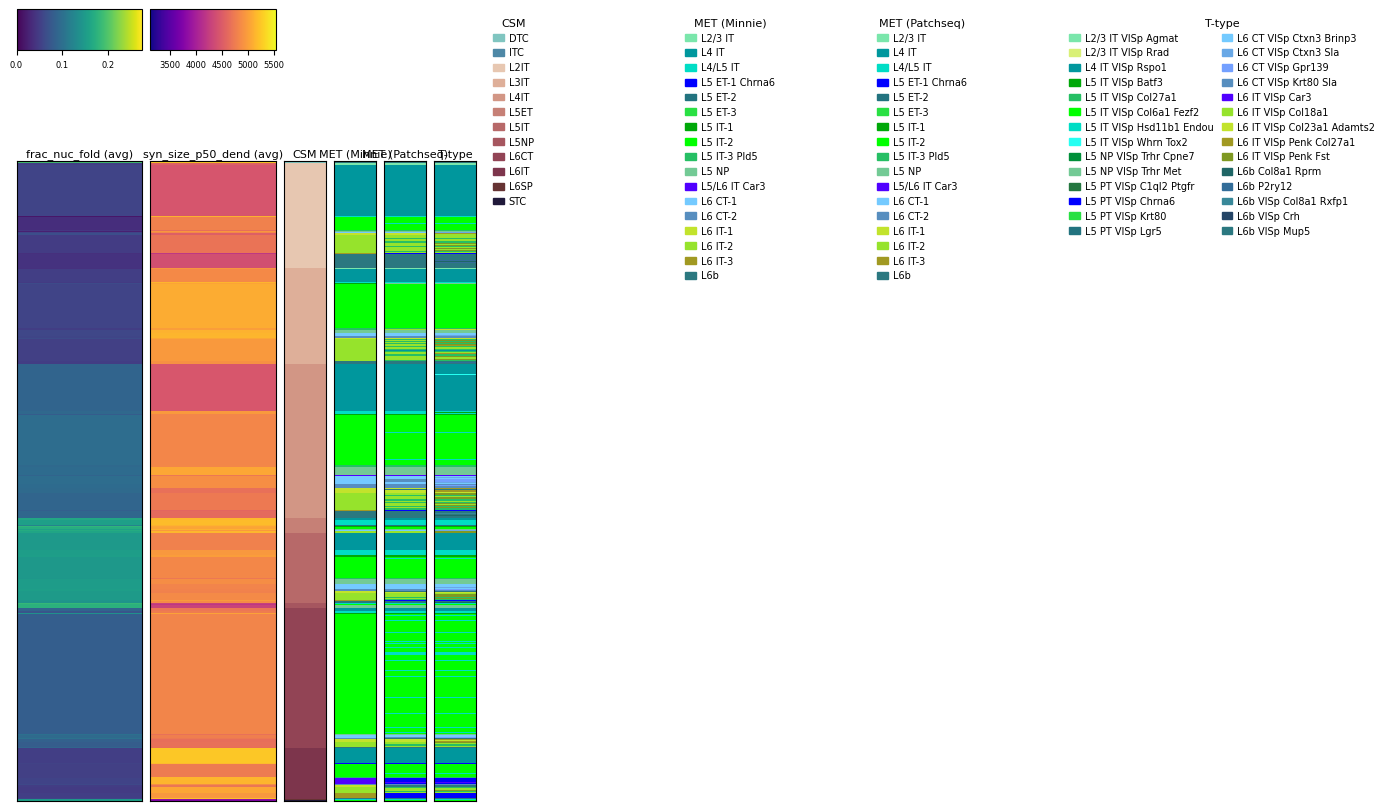

In [17]:
# Demo 5 (cell-to-cell): Minnie features + patchseq neighbor labels — aligned by MET type
# Instead of stretching patchseq rows to match Minnie counts, each Minnie cell is
# directly paired with its k-th nearest patchseq neighbor via lookup_patchseq_neighbors.
# The result is a 1:1 DataFrame — no row duplication needed.

K_NEIGHBOR = 1  # which nearest neighbor rank to use (1 = closest)

# ── Left: df_d2 sorted met → csm ─────────────────────────────────────────────
df_left = df_d2.sort_values(["met_label", "csm_label"]).reset_index(drop=True)

# ── Patchseq neighbor labels via cell-to-cell mapping ────────────────────────
df_ps = lookup_patchseq_neighbors(
    minnie_ctc_exc_df,
    patchseq_met_exc_df,
    patchseq_ttype_exc_df,
    k=K_NEIGHBOR,
)

# ── Merge: attach patchseq labels to each Minnie cell ────────────────────────
df_d5 = df_left.merge(df_ps[["id", "ps_met_label", "ps_ttype_label"]], on="id", how="inner")
df_d5 = df_d5.sort_values(["met_label", "csm_label"]).reset_index(drop=True)
print(f"Demo 5 (cell-to-cell): {len(df_d5):,} cells  (k={K_NEIGHBOR})")

fig = plot_strips(
    df_d5,
    features=[
        {"col": "fraction_nuclear_folding",           "title": "frac_nuc_fold",     "cmap": "viridis"},
        {"col": "syn_size_distribution_dendrite_p50", "title": "syn_size_p50_dend", "cmap": "plasma"},
    ],
    labels=[
        {"col": "csm_label",      "title": "CSM",            "colors": csm_colors},
        {"col": "met_label",      "title": "MET (Minnie)",   "colors": met_colors},
        {"col": "ps_met_label",   "title": "MET (Patchseq)", "colors": met_colors},
        {"col": "ps_ttype_label", "title": "T-type",         "colors": ttype_colors},
    ],
    sort_by=["csm_label", "met_label"],
    average_by=["csm_label", "met_label"],
    colorbar_position="top",
)
plt.show()
